Используйте базу акций Лукойла.

Сделайте несколько усовершенствований в предсказании временного ряда.
Добавьте к исходному сигналу расширенные данные:

* попарные разности каналов
* модули попарных разностей каналов
* попарные произведения каналов
* обратное значение каналов x_new = 1/(x + 1e-3)
* первые производные каналов (x[n] - x[n-1])
* вторые производные каналов (x[n] - 2*x[n-1] + x[n-2])

Примените абсолютно новый подход. Сделайте бОльший “просмотр сети в прошлое”, при формировании входного сигнала используйте:

* 100 точек с шагом назад по 1,

* 100 точек с шагом назад по 10 (или сами точки, или среднее по отрезку в 10 точек).
* Объедините эти точки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, LSTM, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

TICKER = 'LKOH.ME'
START_DATE = '2010-01-01'
SAVE_FILE = '1luk.csv'
TARGET_COL = 3

quotes = yf.download(TICKER, start=START_DATE)


# Отдельно сохраняем цену закрытия в файл
if isinstance(quotes.columns, pd.MultiIndex):
    close_series = quotes[('Close', TICKER)]
else:
    close_series = quotes['Close']

close_frame = close_series.to_frame(name='CLOSE')
close_frame.to_csv(SAVE_FILE)

print(f'Данные скачаны и сохранены в {SAVE_FILE}')


def make_extra_features(source_array):
    # Берём исходные числовые колонки
    result_columns = [col for col in source_array.T]

    # Добавляем взаимодействия признаков
    columns_count = source_array.shape[1]

    for left_col in range(columns_count):
        for right_col in range(left_col + 1, columns_count):
            left_values = source_array[:, left_col]
            right_values = source_array[:, right_col]

            result_columns.append(left_values - right_values)
            result_columns.append(np.abs(left_values - right_values))
            result_columns.append(left_values * right_values)

    # Добавляем обратные значения признаков
    for col_id in range(columns_count):
        result_columns.append(1 / (source_array[:, col_id] + 1e-3))

    expanded = np.array(result_columns).T

    # Первая производная показывает изменение признаков между соседними днями
    first_delta = np.diff(expanded, axis=0, prepend=expanded[0:1, :])

    # Вторая производная показывает изменение самой скорости изменения
    second_delta = np.diff(first_delta, axis=0, prepend=first_delta[0:1, :])

    # Объединяем исходные расширенные и производные признаки
    return np.hstack([expanded, first_delta, second_delta])


raw_values = quotes.values
prepared_values = make_extra_features(raw_values)

print(f'Количество признаков после расширения: {prepared_values.shape[1]}')


# Масштабируем признаки
scaler = StandardScaler()
data_scaled = scaler.fit_transform(prepared_values)

/tmp/ipykernel_931/1506597207.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  quotes = yf.download(TICKER, start=START_DATE)
[*********************100%***********************]  1 of 1 completed

Данные скачаны и сохранены в 1luk.csv
Количество признаков после расширения: 120


In [2]:
def build_sequence_dataset(series_matrix, target_index, window_size=100, step=1):
    samples = []
    answers = []

    for row_id in range(window_size, len(series_matrix)):
        samples.append(series_matrix[row_id - window_size:row_id:step])
        answers.append(series_matrix[row_id, target_index])

    return np.array(samples), np.array(answers)


def split_by_time(features, targets, train_part=0.8):
    border = int(len(features) * train_part)

    x_tr = features[:border]
    x_val = features[border:]
    y_tr = targets[:border]
    y_val = targets[border:]

    return x_tr, x_val, y_tr, y_val


X_pro, y_pro = build_sequence_dataset(
    data_scaled,
    target_index=TARGET_COL,
    window_size=100,
    step=1
)

x_train, x_test, y_train, y_test = split_by_time(X_pro, y_pro, train_part=0.8)

In [3]:
def create_pro_model(input_shape):
    network = Sequential([
        Conv1D(128, 5, activation='relu', input_shape=input_shape),
        BatchNormalization(),

        LSTM(64, return_sequences=False),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1)
    ])

    network.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='mse',
        metrics=['mae']
    )

    return network


model_pro = create_pro_model(
    input_shape=(x_train.shape[1], x_train.shape[2])
)

history = model_pro.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.1731 - mae: 0.3193 - val_loss: 1.4601 - val_mae: 1.1387
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0516 - mae: 0.1763 - val_loss: 0.9120 - val_mae: 0.8773
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0408 - mae: 0.1542 - val_loss: 0.6815 - val_mae: 0.7375
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0366 - mae: 0.1477 - val_loss: 0.5697 - val_mae: 0.6586
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0322 - mae: 0.1379 - val_loss: 0.4680 - val_mae: 0.5731
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0285 - mae: 0.1305 - val_loss: 0.4114 - val_mae: 0.5229
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0275 - mae: 0.1283 - val_loss: 0.3721 - val_mae: 0.4840
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0248 - mae: 0.1217 - val_loss: 0.3586 - val_mae: 0.4661
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.024

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


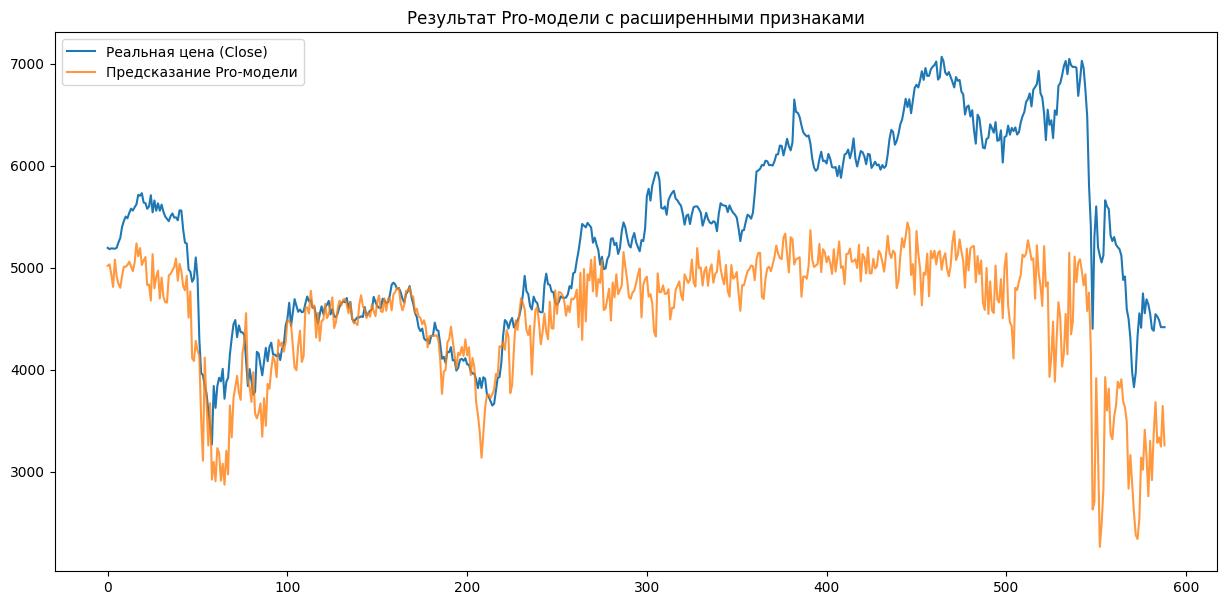

In [4]:
def restore_scaled_column(values, scaler_object, column_id=TARGET_COL):
    buffer = np.zeros((len(values), scaler_object.n_features_in_))
    buffer[:, column_id] = np.asarray(values).reshape(-1)

    restored = scaler_object.inverse_transform(buffer)
    return restored[:, column_id]


def show_price_forecast(real_price, predicted_price):
    # Сравниваем реальные значения с прогнозом модели
    plt.figure(figsize=(15, 7))
    plt.plot(real_price, label='Реальная цена (Close)')
    plt.plot(predicted_price, label='Предсказание Pro-модели', alpha=0.8)
    plt.title('Результат Pro-модели с расширенными признаками')
    plt.legend()
    plt.show()


pred = model_pro.predict(x_test)

y_pred_orig = restore_scaled_column(pred, scaler, TARGET_COL)
y_true_orig = restore_scaled_column(y_test, scaler, TARGET_COL)

show_price_forecast(y_true_orig, y_pred_orig)